In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import seaborn as sns
from typing import Optional
import pandas as pd
import numpy as np
from scipy import sparse
from anndata import AnnData

def plot_age_prediction(adata):
    from sklearn.metrics import r2_score
    from scipy.stats import spearmanr
    import seaborn as sns
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(6, 6))

    datasets = adata.obs['dataset'].unique()
    for dataset in datasets:
        subset = adata.obs[adata.obs['dataset'] == dataset]
        age = subset['age']
        pred = subset['predicted_age']

        r2 = r2_score(age, pred)
        rho, _ = spearmanr(age, pred)

        label = f"{dataset} (ρ={rho:.2f}, R²={r2:.2f})"
        sns.scatterplot(x=age, y=pred, s=10, ax=ax, label=label)

    # Plot diagonal reference line
    min_age = adata.obs['age'].min()
    max_age = adata.obs['age'].max()
    ax.plot([min_age, max_age], [min_age, max_age], 'r--', label="Identity")

    ax.set_xlabel("True Age")
    ax.set_ylabel("Predicted Age")
    ax.legend()
    ax.set_title("Age Prediction per Dataset")
    plt.tight_layout()
    plt.show()

# Prepare data

In [6]:
import anndata as ad
from ciim.src.clock.helper import save_function, merge_adata, align_feature_space

data_type = 'bulk'
feature_type = 'gene_expression'
cell_type = 'CD8T'
age_limit = 20

adata_train = merge_adata(['data1', 'data7_allTPs_jalil'], 
                          feature_type, cell_type, data_type, age_limit=age_limit)
adata_test = merge_adata(['SLE_European'], feature_type, cell_type, data_type, age_limit=age_limit)
adata_test = align_feature_space(adata_test, gene_names=adata_train.var_names.tolist())

# Create models

In [4]:
import torch
from scvi.dataloaders import AnnDataLoader

In [42]:
from ciim.src.clock.train import build_model
model, model_kwargs = build_model(reg_type='NN', adata=adata_train,  tune_model=False, temp_dir=None)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 400/400: 100%|██████████| 400/400 [02:07<00:00,  3.13it/s, v_num=1, train_loss_step=226, train_loss_epoch=389]      

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [02:07<00:00,  3.13it/s, v_num=1, train_loss_step=226, train_loss_epoch=389]


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


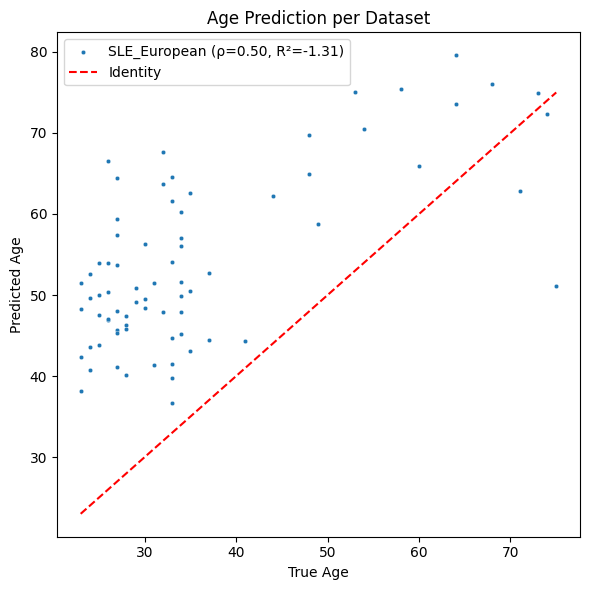

In [43]:
adata = model.predict_age(adata_test)
plot_age_prediction(adata)

In [44]:

# adata = adata_train
# myModel.setup_anndata(adata, batch_key="dataset", labels_key="age")
# model = myModel(adata, n_latent=100, batch_emb_dim=10)
# model.train(max_epochs=2)

# model.extend_batch_embedding(adata_test)
# myModel.setup_anndata_test(adata_test)

# model.train_test(adata_test, max_epochs=2)

In [45]:
# # - freeze the model parameters
# for param in model.module.parameters():
#     param.requires_grad = False

In [46]:
# # Unfreeze the new embeddings
# embed_layer = model.module.batch_embed
# n_old = embed_layer.num_embeddings - embed_layer.additional_embeddings.shape[0]
# embed_layer.additional_embeddings.requires_grad_(True)

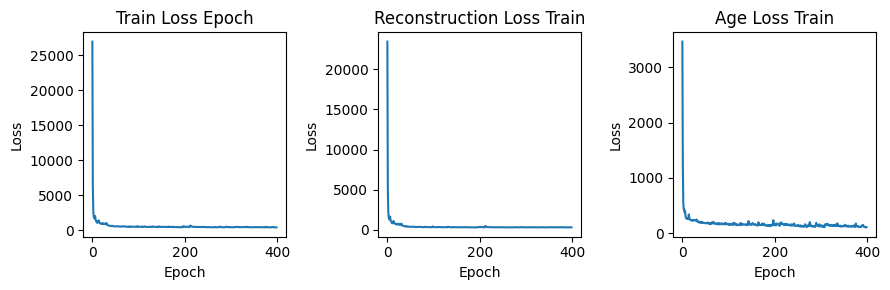

In [47]:
history = model.history
import seaborn as sns
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for i, key in enumerate(['train_loss_epoch', 'reconstruction_loss_train', 'age_loss_train']):
    sns.lineplot(data=history[key], ax=axes[i])
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Loss")
    axes[i].set_title(key.replace('_', ' ').title())
    axes[i].get_legend().remove()
plt.tight_layout()

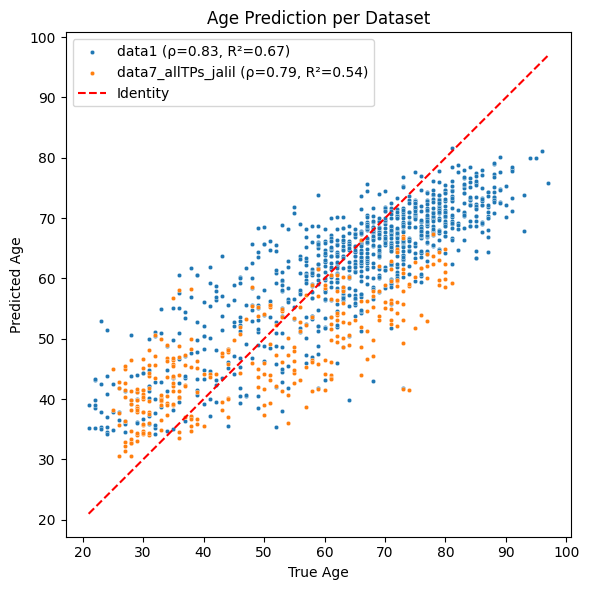

In [48]:
adata_train = model.predict_age(adata_train)
plot_age_prediction(adata_train)

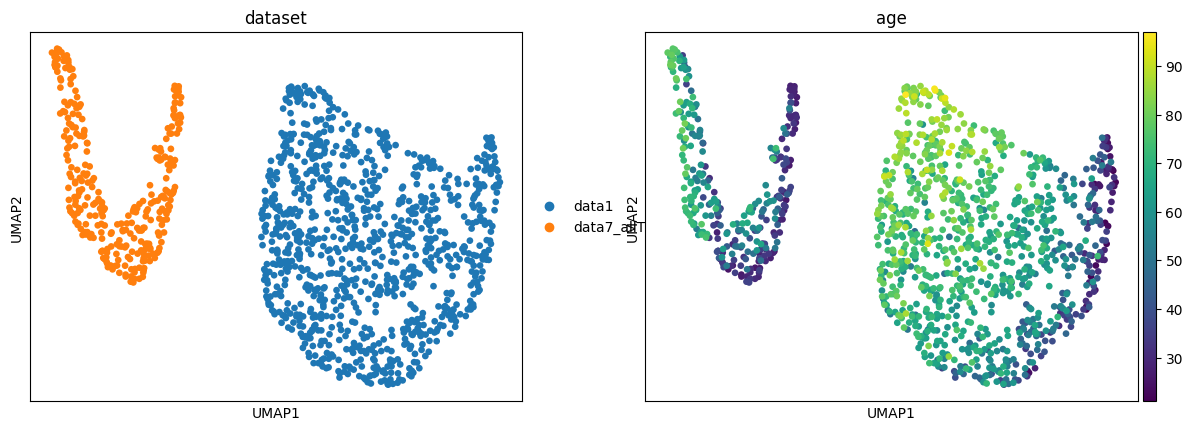

In [49]:
import scanpy as sc
X_latent = model.get_latent_representation(return_dist=False, give_mean=True)
model.adata.obsm["X_latent"] = X_latent
sc.pp.neighbors(model.adata, use_rep="X_latent")
sc.tl.umap(model.adata)
sc.pl.umap(model.adata, color=["dataset", "age"])  # adjust based on your obs keys

In [50]:
if False:
    import os
    import shutil
    from ciim.src.clock.NN.NN import VAEAgeModel
    model_dir = os.path.join('./', "saved_model")

    if os.path.exists(model_dir) and os.path.isdir(model_dir):
        shutil.rmtree(model_dir)
    
    model.save(model_dir, save_anndata=True)
    model = VAEAgeModel.load(model_dir)